In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate
from gurobipy import GRB
import glob
import pickle
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv('out/results.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'out/results.csv'

In [ ]:
from networkx.utils import graphs_equal
def assert_equivalence(path):
    models = {}
    for model in glob.glob(f'{path}*.pickle'):
        model_name = model.split('model_')[1].split('_')[0]
        if model_name not in models:
            models[model_name] = [model]
        else:
            models[model_name].append(model)
    for k in models:
        if 'bpic' not in k and 'greps' not in k:
            continue
        m_base = None
        with open(models[k][0], 'rb') as handle:
            m_base = pickle.load(handle)
        for m in models[k][1:]:
            m_current = None
            with open(m, 'rb') as handle:
                m_current = pickle.load(handle)
            assert graphs_equal(m_current,m_base), f'{models[k][0]}, {m}, m_current.nodes()'
        print("Is equal", k)
assert_equivalence('out/models/')

Is equal greps
Is equal bpic12


In [7]:
def transform_model_name(s):
    if 'greps' in s:
        return 'Greps'
    if 'bpic12' in s:
        return "BPIC'12"
    if 'bpic17-before' in s:
        return "BPIC'17-1"
    if 'bpic17-after' in s:
        return "BPIC'17-2"
    if 'bpic17-both' in s:
        return "BPIC'17"
    if 'spotify' in s:
        s = s.replace('spotify', '')
        return 'MSSD'+s
        # if s[-4:-2] == "00":
        #     return 'MSSD100'
        # return f'MSSD{s[-4:-2]}'
    assert False, s

In [ ]:
def model_information(path):
    print()
    info_dict = {'states' : {}, 'transitions' : {}, 'max_degree' : {}}
    for model in glob.glob(f'{path}*.pickle'):
        model_name = model.split('model_')[1].split('_')[0]
        model_name = transform_model_name(model_name)
        with open(model, 'rb') as handle:
            model = pickle.load(handle)
        if model_name not in info_dict['states']:
            info_dict['transitions'][model_name] = []
            info_dict['states'][model_name] = []
            info_dict['max_degree'][model_name] = []
        info_dict['states'][model_name].append(len(model.nodes()))
        info_dict['transitions'][model_name].append(len(model.edges()))
        degree_sequence = sorted((d for n, d in model.degree()), reverse=True)
        dmax = max(degree_sequence)
        info_dict['max_degree'][model_name].append(dmax)
    for k in info_dict:
        for k_inner in info_dict[k]:
            info_dict[k][k_inner] = sum(info_dict[k][k_inner])/len(info_dict[k][k_inner])
    print(info_dict)
    df = pd.DataFrame(data = info_dict)
    # df = pd.DataFrame(data={'States' : info_dict['states'], 'Transitions' : info_dict['transitions']}, index = info_dict['states'].keys())
    df.rename(columns = {'states' : 'States', 'transitions' : 'Transitions'}, inplace=True)
    
    s = ['Greps', "BPIC'12", "BPIC'17"]
    s.extend([f'MSSD{i*10}' for i in range(1,11)])
    print(s)
    df = df.reindex(s)
    
    print(df.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.1f}".format, bold_rows = True,
    ))
    
    return df
model_information('out/models/')


{'states': {'Greps': 64.0, "BPIC'12": 129.0}, 'transitions': {'Greps': 76.0, "BPIC'12": 288.0}, 'max_degree': {'Greps': 6.0, "BPIC'12": 28.0}}
['Greps', "BPIC'12", "BPIC'17", 'MSSD10', 'MSSD20', 'MSSD30', 'MSSD40', 'MSSD50', 'MSSD60', 'MSSD70', 'MSSD80', 'MSSD90', 'MSSD100']


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

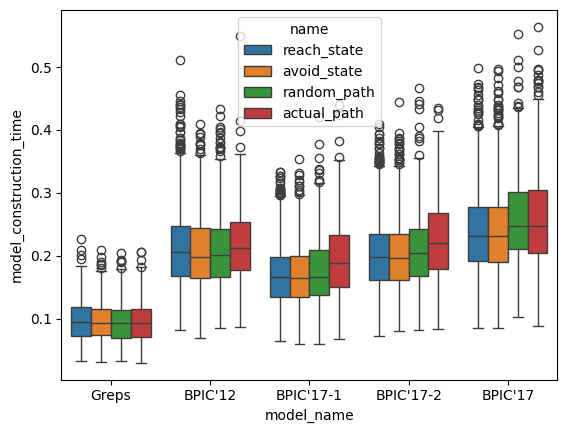

<Axes: xlabel='model_name', ylabel='model_checking_time'>

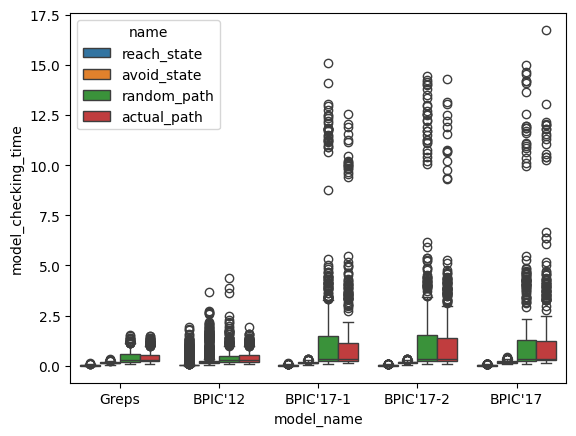

In [ ]:
df = pd.read_csv('out/results_bpic.csv')

# all paths have > 0 probability for reaching - must not hold for paths, e.g. reach_avoid
assert (df[df['name'].str.contains('path')]['value']>0).all

df['model_name'] = df['model'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
sns.boxplot(data=df, x="model_name", y="model_construction_time", hue="name")
plt.show()

sns.boxplot(data=df, x="model_name", y="model_checking_time", hue="name")

<Axes: xlabel='model_name', ylabel='model_checking_time'>

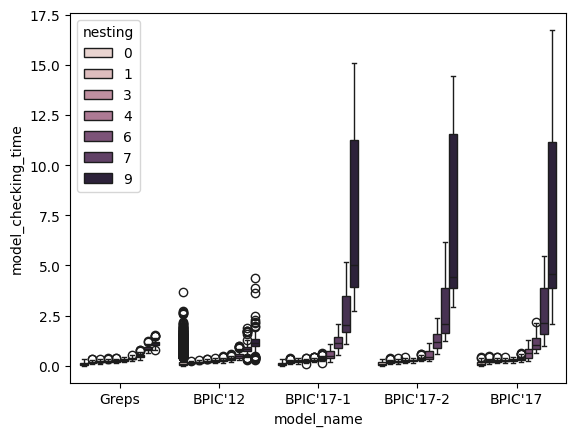

In [ ]:
df_bpic = df[df['model_name']!='Greps']
df_bpic_paths = df_bpic[df_bpic['name'].str.contains('path')]
sns.boxplot(data=df, x="model_name", y="model_checking_time", hue="nesting")

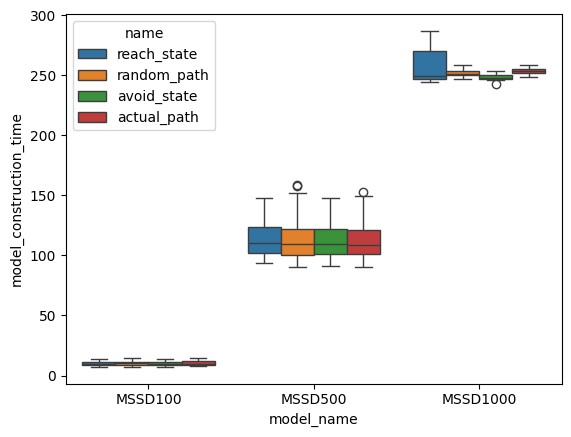

<Axes: xlabel='model_name', ylabel='model_checking_time'>

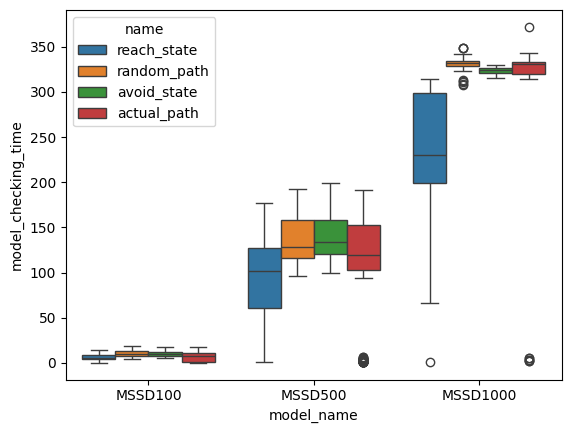

In [ ]:
df = pd.read_csv('out/results_spotify_100-500.csv')
df = pd.concat([df,pd.read_csv('out/results_1000.csv')], axis=0, ignore_index=True) 
df = df[df['value'] != -1]

# all paths have > 0 probability for reaching - must not hold for paths, e.g. reach_avoid
assert (df[df['name'].str.contains('path')]['value']>0).all

df['model_name'] = df['model'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
sns.boxplot(data=df, x="model_name", y="model_construction_time", hue="name")
plt.show()

sns.boxplot(data=df, x="model_name", y="model_checking_time", hue="name")

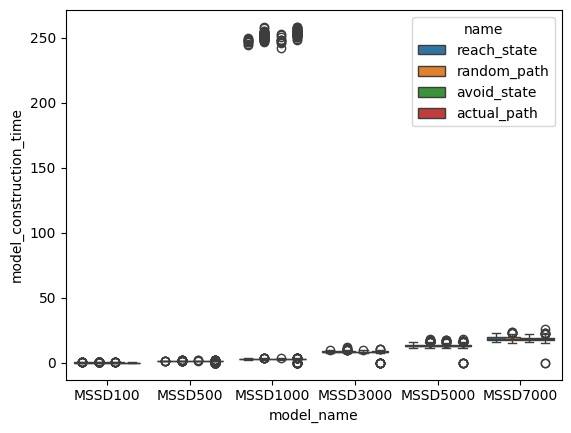

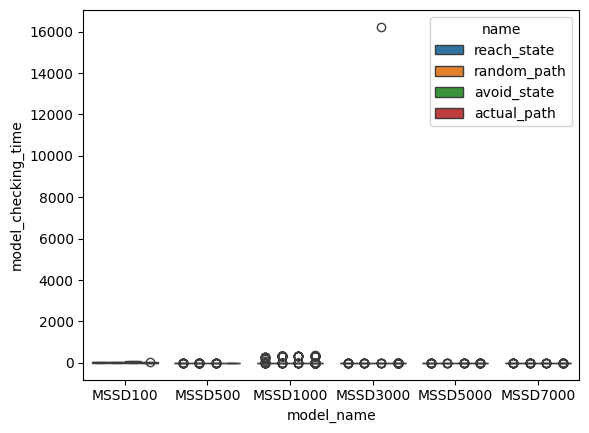

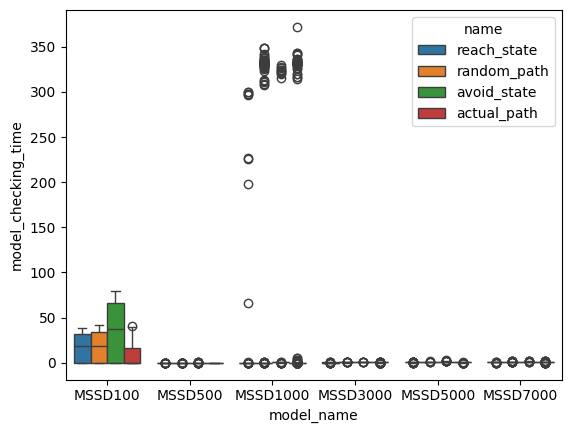

,Unnamed: 0,model,query,nesting,value,model_parsing_time,model_checking_time,model_construction_time,name,timeout,solver,model_name
303,0,out/models/model_spotify100_model-it_1.prism,"Pmax=? [(F ""positive"") & (!(""positive"") U loc=...",0,5186670075369009330209454764229219498622867753...,0.103,76.419,0.207,avoid_state,3600,storm,MSSD100
310,0,out/models/model_spotify100_model-it_1.prism,"Pmax=? [(F ""positive"") & (!(""positive"") U loc=...",0,5260019614254047980426795415245067771603314429...,0.095,77.239,0.197,avoid_state,3600,storm,MSSD100
311,0,out/models/model_spotify100_model-it_1.prism,"Pmax=? [(F ""positive"") & (!(""positive"") U loc=...",0,1037334015073801794465843912753516144898756365...,0.101,77.362,0.214,avoid_state,3600,storm,MSSD100
312,0,out/models/model_spotify100_model-it_1.prism,"Pmax=? [(F ""positive"") & (!(""positive"") U loc=...",0,2083713048944126327545141565646766958318413395...,0.166,77.382,0.210,avoid_state,3600,storm,MSSD100
315,0,out/models/model_spotify100_model-it_1.prism,"Pmax=? [(F ""positive"") & (!(""positive"") U loc=...",0,5260019614254047980426795415245067771603314429...,0.119,77.527,0.209,avoid_state,3600,storm,MSSD100
...,...,...,...,...,...,...,...,...,...,...,...,...
6705,0,out/models/model_spotify1000_model-it_0.prism,"Pmax=? [(F ""positive"") & ((X( loc=1 & ((X( loc...",7,0.000046,330.323,330.323,255.609,actual_path,3600,prism,MSSD1000
6706,0,out/models/model_spotify1000_model-it_0.prism,"Pmax=? [(F ""positive"") & ((X( loc=1 & ((X( loc...",8,0.000655,341.970,341.970,253.079,actual_path,3600,prism,MSSD1000
6707,0,out/models/model_spotify1000_model-it_0.prism,"Pmax=? [(F ""positive"") & ((X( loc=1 & ((X( loc...",8,0.000324,331.475,331.475,250.911,actual_path,3600,prism,MSSD1000
6708,0,out/models/model_spotify1000_model-it_0.prism,"Pmax=? [(F ""positive"") & ((X( loc=1 & ((X( loc...",9,0.000496,343.205,343.205,253.981,actual_path,3600,prism,MSSD1000


In [ ]:
df = pd.read_csv('out/results_spotify_storm.csv')
df = pd.concat([df,pd.read_csv('out/results_1000.csv')], axis=0, ignore_index=True) 
df = df[df['value'] != -1]

# all paths have > 0 probability for reaching - must not hold for paths, e.g. reach_avoid
# assert (df[df['name'].str.contains('path')]['value']>0).all

df['model_name'] = df['model'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)
sns.boxplot(data=df, x="model_name", y="model_construction_time", hue="name")
plt.show()

sns.boxplot(data=df, x="model_name", y="model_checking_time", hue="name")
plt.show()

df = df[df['model_checking_time']<2000]
sns.boxplot(data=df, x="model_name", y="model_checking_time", hue="name")
plt.show()

df[df['model_checking_time']>50]

In [ ]:
def plot_results_df(path):
    df = pd.read_csv(path)
    df = df[df['id'] == 0]
    
    df['model_name'] = df['model'].str.split('model_').str[1].str.split('_').str[0]
    df['model_name'] = df['model_name'].apply(transform_model_name)
    
    
    # df['target_prob_quantile'] = pd.qcut(df['target_prob'], 10, labels=False)
    df_grouped = df.groupby('model_name')['time'].agg(['mean','std', 'min', 'max']).reset_index()
    
    df_grouped.rename(columns = {'mean' : 'mean(t)', 'std' : 'std(t)', 'min' : 'min(t)', 'max' : 'max(t)', 'model_name' : 'Model'}, inplace=True)
    
    
    df_groped_not_agg = df.groupby(['model_name', 'status']).size()
    recorded_status = df['status'].values
    
    # df_grouped['Opt.'] = df_groped_not_agg.loc[df_grouped['Model'].values, GRB.OPTIMAL].values if GRB.OPTIMAL in recorded_status else 0
    # df_grouped['Inf.'] = df_groped_not_agg.loc[df_grouped['Model'].values, GRB.INFEASIBLE].values if GRB.INFEASIBLE in recorded_status else 0
    # df_grouped['T.O.'] = df_groped_not_agg.loc[df_grouped['Model'].values, GRB.TIME_LIMIT].values if GRB.TIME_LIMIT in recorded_status else 0 
    # df_grouped['M.O.'] = df_groped_not_agg.loc[df_grouped['Model'].values, GRB.MEM_LIMIT].values if GRB.MEM_LIMIT in recorded_status else 0
    
    df_grouped['T.O.'].astype(object) 
    
    #df = df.groupby('model_name').mean().reset_index()
    
    print(tabulate(df_grouped.round(2), headers='keys', tablefmt='psql'))
    df_grouped.set_index("Model", inplace=True)
    df_grouped = df_grouped.reindex(['Greps', "BPIC'12", "BPIC'17"])
    
    print(df_grouped.to_latex(index=True,
                formatters={"name": str.upper},
                float_format="{:.2f}".format, bold_rows = True,
    ))
        
plot_results_df('out/results_bpic.csv')

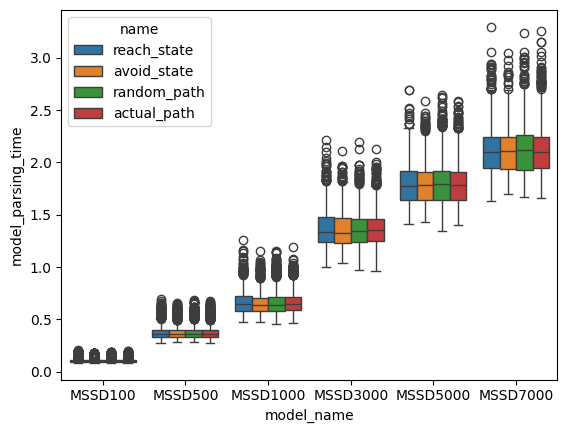

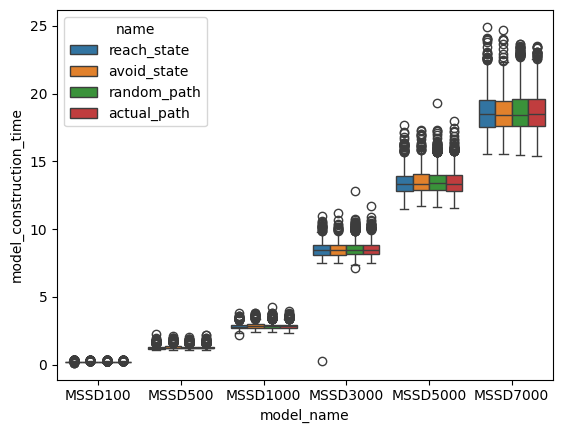

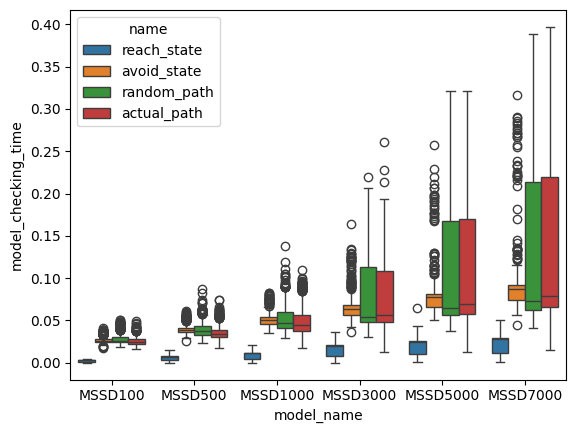

In [10]:
df = pd.read_csv('out/results_storm_not_exact.csv')
df = df[df['value'] != -1]

# all paths have > 0 probability for reaching - must not hold for paths, e.g. reach_avoid
# assert (df[df['name'].str.contains('path')]['value']>0).all

df['model_name'] = df['model'].str.split('model_').str[1].str.split('_').str[0]
df['model_name'] = df['model_name'].apply(transform_model_name)

sns.boxplot(data=df, x="model_name", y="model_parsing_time", hue="name")
plt.show()

sns.boxplot(data=df, x="model_name", y="model_construction_time", hue="name")
plt.show()

sns.boxplot(data=df, x="model_name", y="model_checking_time", hue="name")
plt.show()